In [1]:
# Setup

import os
os.environ["OMP_NUM_THREADS"] = "14"

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", message="zero-centering a sparse array")
warnings.filterwarnings("ignore", message="IProgress not found")
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

adata = sc.read_h5ad(ROOT / "data/pbmc3k.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 2638 × 13656
    obs: 'cell_type'
    var: 'gene_ids', 'n_cells'
    obsm: 'X_umap_ref'
    layers: 'counts'


In [2]:
# Preprocessing

adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
print("HVGs selected:", adata.var.highly_variable.sum(), "of", adata.n_vars)

adata.raw = adata
adata = adata[:, adata.var.highly_variable].copy()

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack", n_comps=50)
print(adata)


HVGs selected: 2000 of 13656
AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'cell_type'
    var: 'gene_ids', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_umap_ref', 'X_pca'
    varm: 'PCs'
    layers: 'counts'


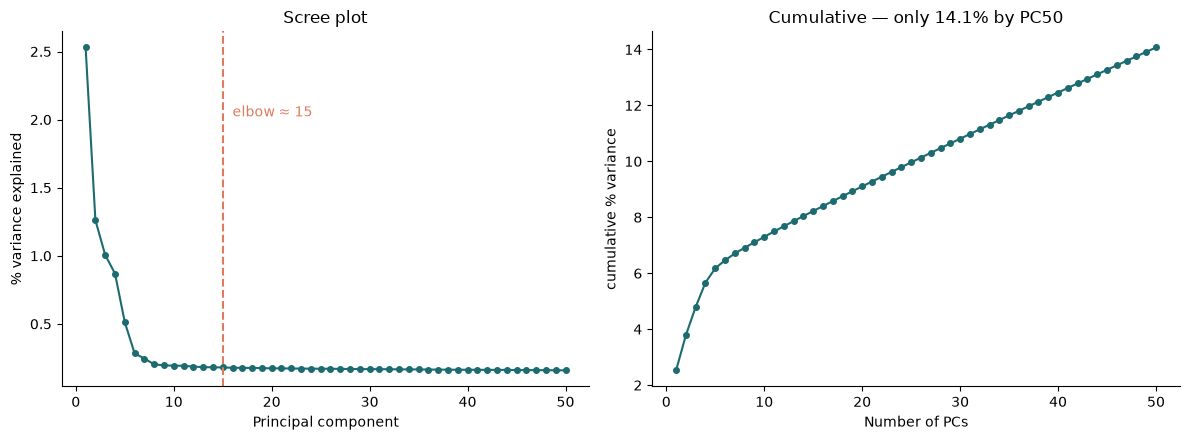

PC1-5 : [2.53 1.26 1.01 0.87 0.51]
PC10  : 0.19
PC30  : 0.17
PC50  : 0.16
cumulative to PC50: 14.1 %


In [3]:
# 3 — The elbow plot
(ROOT / "figures").mkdir(exist_ok=True)

vr = adata.uns["pca"]["variance_ratio"] * 100
cum = np.cumsum(vr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(range(1, 51), vr, "o-", color="#1B6B70", ms=4, lw=1.5)
ax.axvline(15, ls="--", c="#E07A5F", lw=1.5)
ax.text(16, vr.max()*0.8, "elbow ≈ 15", color="#E07A5F", fontsize=10)
ax.set_xlabel("Principal component")
ax.set_ylabel("% variance explained")
ax.set_title("Scree plot")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.plot(range(1, 51), cum, "o-", color="#1B6B70", ms=4, lw=1.5)
ax.set_xlabel("Number of PCs")
ax.set_ylabel("cumulative % variance")
ax.set_title(f"Cumulative — only {cum[49]:.1f}% by PC50")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(ROOT / "figures/scree_pbmc3k.png", dpi=150, bbox_inches="tight")
plt.show()

print("PC1-5 :", np.round(vr[:5], 2))
print("PC10  :", round(vr[9], 2))
print("PC30  :", round(vr[29], 2))
print("PC50  :", round(vr[49], 2))
print("cumulative to PC50:", round(cum[49], 1), "%")


In [4]:
import pandas as pd
(ROOT / "results").mkdir(exist_ok=True)

var_tab = pd.DataFrame({
    "PC": range(1, 51),
    "pct_variance": np.round(vr, 3),
    "cumulative_pct": np.round(cum, 2),
})
var_tab.to_csv(ROOT / "results/pca_variance_pbmc3k.csv", index=False)
print(var_tab.head(10))

   PC  pct_variance  cumulative_pct
0   1         2.530            2.53
1   2         1.262            3.79
2   3         1.006            4.80
3   4         0.870            5.67
4   5         0.513            6.18
5   6         0.284            6.46
6   7         0.245            6.71
7   8         0.203            6.91
8   9         0.195            7.11
9  10         0.194            7.30


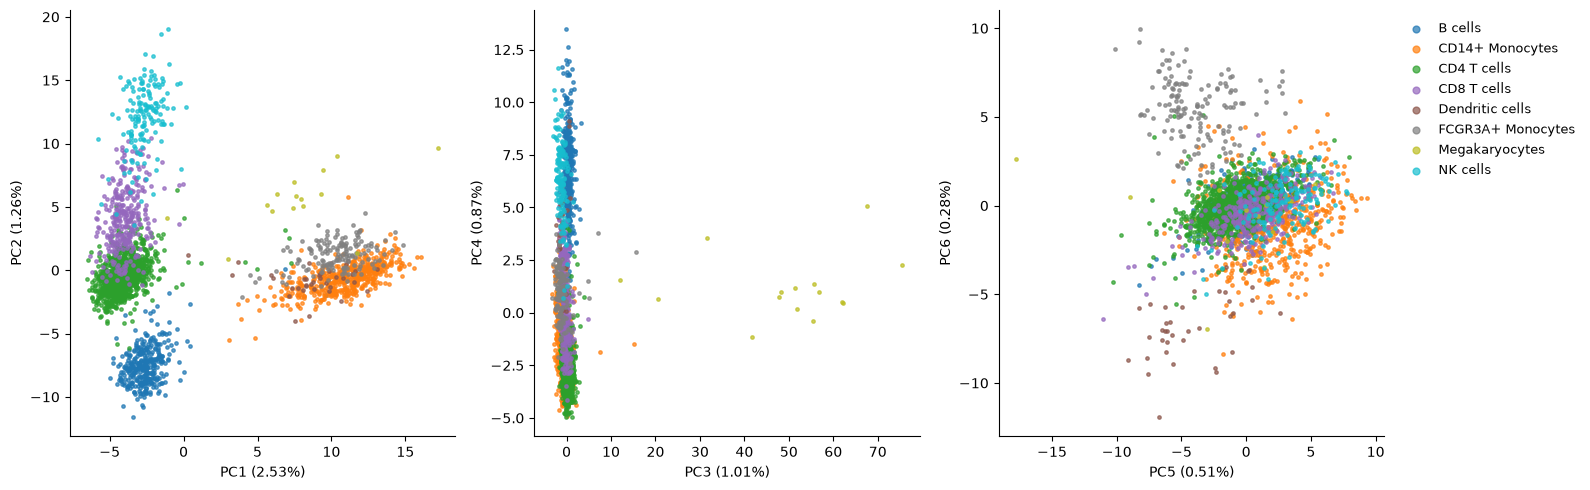

In [5]:
# 4 — What the PCs actually separate

pcs = adata.obsm["X_pca"]
types = adata.obs["cell_type"].astype(str)
cats = sorted(types.unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(cats)))
cmap = dict(zip(cats, colors))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (a, b) in zip(axes, [(0, 1), (2, 3), (4, 5)]):
    for c in cats:
        m = (types == c).values
        ax.scatter(pcs[m, a], pcs[m, b], s=6, color=cmap[c], label=c, alpha=0.7)
    ax.set_xlabel(f"PC{a+1} ({vr[a]:.2f}%)")
    ax.set_ylabel(f"PC{b+1} ({vr[b]:.2f}%)")
    ax.spines[["top", "right"]].set_visible(False)

axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left",
               frameon=False, markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / "figures/pca_components_pbmc3k.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
for n in [5, 15, 30, 50]:
    sc.pp.neighbors(adata, n_pcs=n, n_neighbors=15, key_added=f"nn{n}")
    sc.tl.umap(adata, neighbors_key=f"nn{n}")
    adata.obsm[f"X_umap_{n}"] = adata.obsm["X_umap"].copy()
    print(f"{n} PCs done")

5 PCs done
15 PCs done
30 PCs done
50 PCs done


In [7]:
from sklearn.metrics import silhouette_score
import pandas as pd

(ROOT / "results").mkdir(exist_ok=True)

rows = []
for n in [5, 15, 30, 50]:
    s = silhouette_score(adata.obsm["X_pca"][:, :n],
                         adata.obs["cell_type"].astype(str))
    rows.append({"n_pcs": n, "silhouette": round(s, 3)})

sil = pd.DataFrame(rows)
sil.to_csv(ROOT / "results/silhouette_by_npcs.csv", index=False)
print(sil)

   n_pcs  silhouette
0      5       0.398
1     15       0.296
2     30       0.185
3     50       0.129


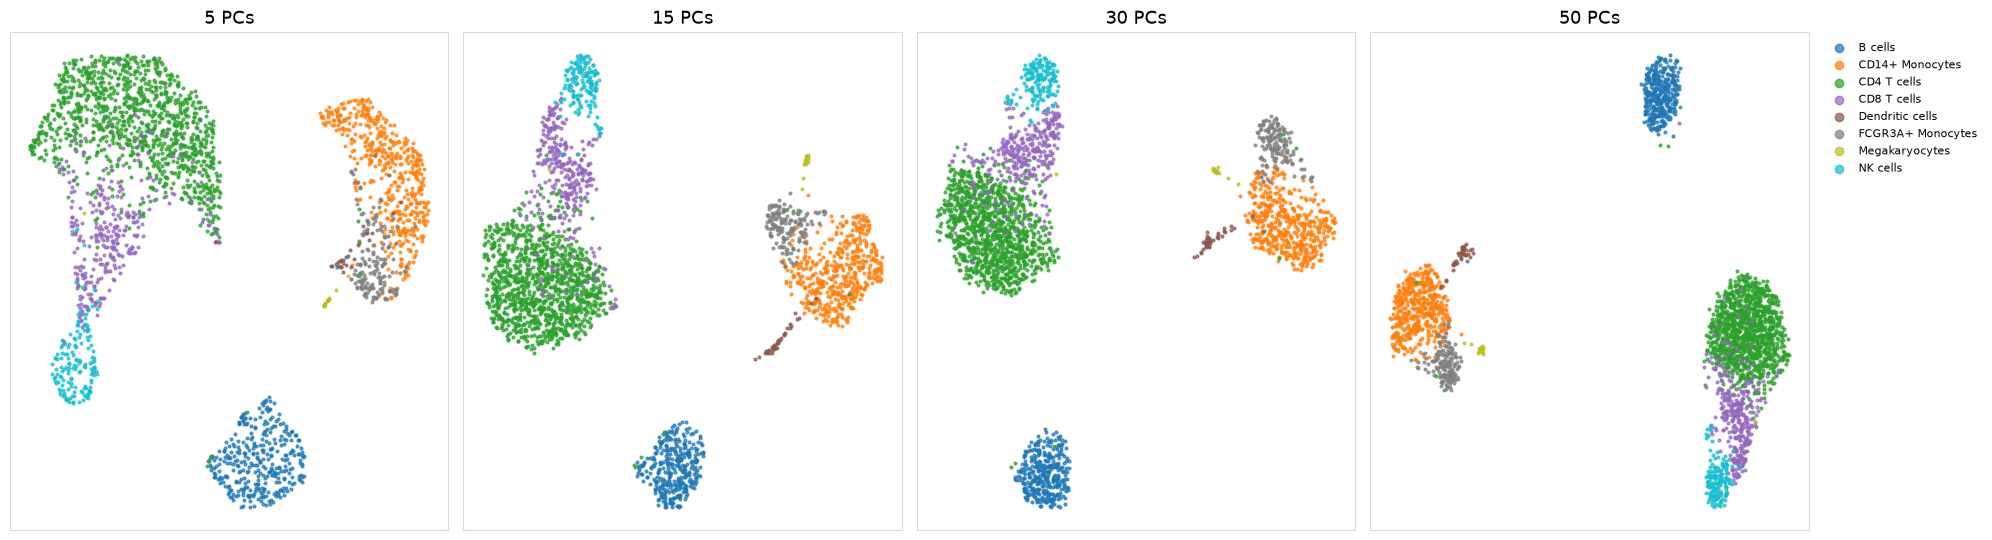

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, n in zip(axes, [5, 15, 30, 50]):
    u = adata.obsm[f"X_umap_{n}"]
    for c in cats:
        m = (types == c).values
        ax.scatter(u[m, 0], u[m, 1], s=4, color=cmap[c], alpha=0.7, label=c)
    padx = 0.05 * (u[:,0].max() - u[:,0].min())
    pady = 0.05 * (u[:,1].max() - u[:,1].min())
    ax.set_xlim(u[:,0].min()-padx, u[:,0].max()+padx)
    ax.set_ylim(u[:,1].min()-pady, u[:,1].max()+pady)
    ax.set_title(f"{n} PCs", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color("0.85")
        s.set_linewidth(0.8)

axes[3].legend(bbox_to_anchor=(1.02, 1), loc="upper left",
               frameon=False, markerscale=3, fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "figures/umap_by_npcs.png", dpi=150, bbox_inches="tight")
plt.show()